# Actividad integradora: Segmentación por color

En esta actividad vas a tomar decisiones propias. Ya viste ejemplos guiados; ahora te toca diseñar una estrategia de segmentación, justificarla y revisar tus resultados.

## Consigna general

Podés trabajar de dos maneras:

- con una imagen de ejemplo del repositorio, o
- con `imagen_preprocesada.png` si antes completaste `007 - recuperacion y preprocesamiento de imagenes propias.ipynb`.

La meta no es solo obtener una máscara "linda", sino explicar por qué elegiste esa estrategia y qué límites encontraste.

## Qué se espera que entregues

- una imagen de entrada,
- una o más máscaras de prueba,
- una versión final segmentada,
- una breve justificación de los umbrales elegidos,
- una reflexión sobre errores, ajustes y límites del método.

## Criterios de evaluación

- claridad en la lectura de la imagen,
- justificación de parámetros,
- capacidad para comparar alternativas,
- interpretación crítica del resultado,
- uso claro del lenguaje técnico.


In [1]:
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def mostrar_canales(imagen_rgb):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    axes[0, 0].imshow(imagen_rgb)
    axes[0, 0].set_title("Imagen original")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(rojo, cmap="gray")
    axes[0, 1].set_title("Canal rojo")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(verde, cmap="gray")
    axes[1, 0].set_title("Canal verde")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(azul, cmap="gray")
    axes[1, 1].set_title("Canal azul")
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()


def mostrar_histogramas(imagen_rgb):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, indice, color, titulo in zip(
        axes,
        [0, 1, 2],
        ["red", "green", "blue"],
        ["Rojo", "Verde", "Azul"],
    ):
        hist, bins = np.histogram(imagen_rgb[:, :, indice].flatten(), bins=256, range=[0, 256])
        ax.plot(bins[:-1], hist, color=color)
        ax.set_title(f"Histograma {titulo}")
        ax.set_xlim(0, 255)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]
    mascara = (
        (rojo >= r_min) & (rojo <= r_max) &
        (verde >= g_min) & (verde <= g_max) &
        (azul >= b_min) & (azul <= b_max)
    )
    return mascara


In [2]:
archivos = {
    "flores": (
        Path("flowers.jpg"),
        "https://www.dropbox.com/s/jetlnfihles3g7k/flowers.jpg?dl=1",
    ),
    "frutos": (
        Path("frutos_rojos.png"),
        "https://www.dropbox.com/s/do6b49d10ty1dyf/frutos_rojos.png?dl=1",
    ),
}

for ruta, url in archivos.values():
    if not ruta.exists():
        urllib.request.urlretrieve(url, ruta)

if Path("imagen_preprocesada.png").exists():
    print("También está disponible: imagen_preprocesada.png")

print("Imágenes listas para la actividad.")


Imágenes listas para la actividad.


## Parte 1. Elegí una imagen y un color objetivo

Si completaste el cuaderno extra de preprocesamiento, te conviene empezar con `imagen_preprocesada.png`. Si no, podés trabajar con `flowers.jpg` o con `frutos_rojos.png`.

Antes de escribir código, anotá qué color querés segmentar y por qué te parece un buen caso para probar.


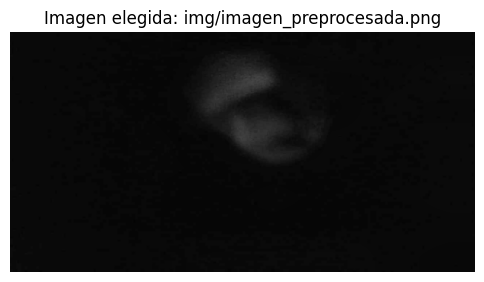

Color objetivo: verde brillante del cuerpo del loro


In [11]:
from pathlib import Path

# Elegí la imagen con la que vas a trabajar
if Path("img/imagen_preprocesada.png").exists():
    nombre_imagen = "img/imagen_preprocesada.png"
else:
    nombre_imagen = "flowers.jpg"  # fallback

imagen_rgb = cargar_rgb(nombre_imagen)

# Descripción
color_objetivo = "verde brillante del cuerpo del loro"

plt.figure(figsize=(6, 6))
plt.imshow(imagen_rgb)
plt.title(f"Imagen elegida: {nombre_imagen}")
plt.axis("off")
plt.show()

print("Color objetivo:", color_objetivo)


## Parte 2. Explorá canales e histogramas

Antes de definir umbrales, mirá la imagen por canales y revisá sus histogramas. La pregunta clave es: ¿qué canal parece más útil para distinguir el color que querés aislar?


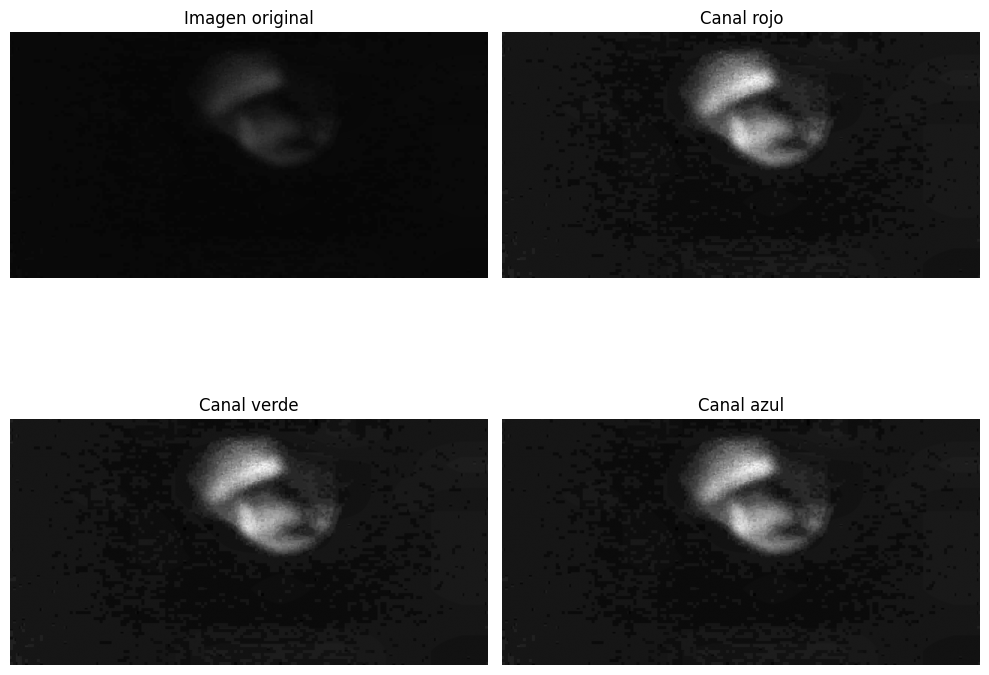

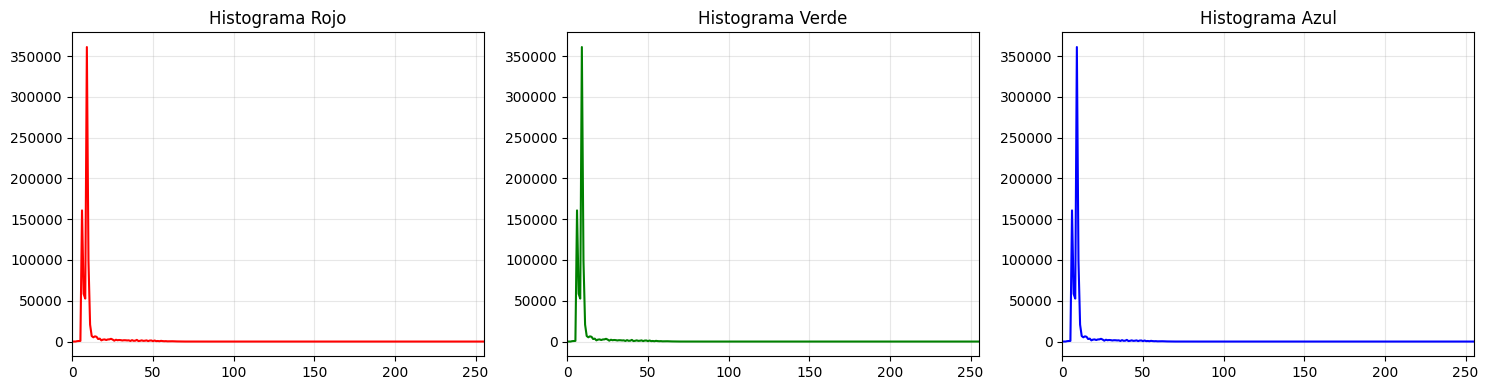

Al observar los canales RGB, se nota que el canal verde presenta mayor intensidad en la zona del loro, lo que permite diferenciarlo del fondo oscuro. A diferencia de la imagen anterior, el objeto no es blanco sino que tiene un color dominante, por lo que un canal específico (verde) aporta más información que los otros. En los histogramas se observa que los píxeles del loro tienden a concentrarse en valores más altos del canal verde, mientras que el fondo se mantiene en valores bajos. Esto sugiere que es posible segmentar el objeto utilizando rangos de color en RGB, especialmente priorizando el canal verde.


In [12]:
mostrar_canales(imagen_rgb)
mostrar_histogramas(imagen_rgb)

# Escribí una observación breve sobre lo que viste.
observacion = (
    "Al observar los canales RGB, se nota que el canal verde presenta mayor intensidad en la zona del loro, "
    "lo que permite diferenciarlo del fondo oscuro. "
    "A diferencia de la imagen anterior, el objeto no es blanco sino que tiene un color dominante, "
    "por lo que un canal específico (verde) aporta más información que los otros. "
    "En los histogramas se observa que los píxeles del loro tienden a concentrarse en valores más altos del canal verde, "
    "mientras que el fondo se mantiene en valores bajos. "
    "Esto sugiere que es posible segmentar el objeto utilizando rangos de color en RGB, "
    "especialmente priorizando el canal verde."
)

print(observacion)


## Parte 3. Diseñá tu primera estrategia de segmentación

Completá los rangos mínimos y máximos para cada canal. No tienen por qué ser perfectos en el primer intento. La idea es que puedas probar, mirar y corregir.


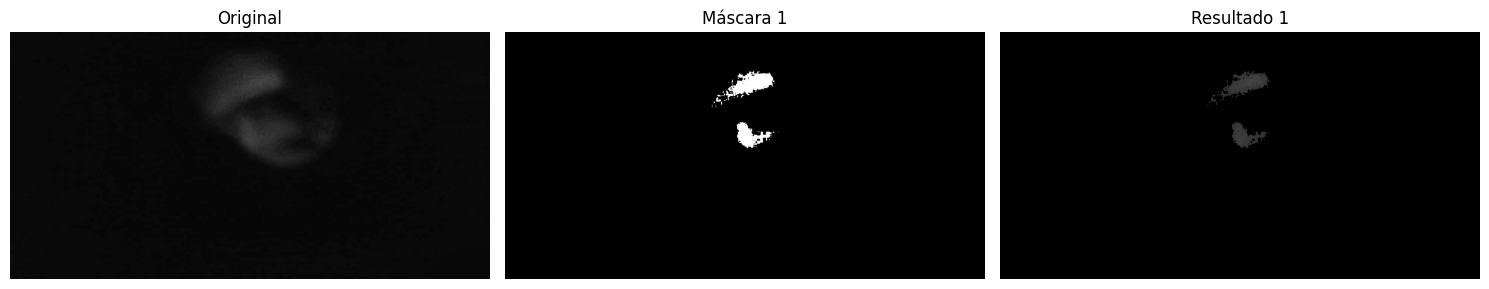

Al ajustar los umbrales en los canales RGB, especialmente aumentando el rango en el canal verde, la máscara logra detectar correctamente la zona del cuerpo del loro. El fondo oscuro queda mayormente excluido, lo que indica que la segmentación es efectiva. Sin embargo, pueden aparecer pequeñas detecciones en otras zonas con colores similares, como áreas amarillas o iluminadas, lo que evidencia una limitación del método basado en RGB. Aun así, la estrategia resulta adecuada como primera aproximación para segmentar el color verde.


In [14]:
r_min, r_max = 50, 255
g_min, g_max = 50, 255
b_min, b_max = 50, 255

mascara_1 = segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max)
resultado_1 = imagen_rgb.copy()
resultado_1[~mascara_1] = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imagen_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mascara_1, cmap="gray")
axes[1].set_title("Máscara 1")
axes[1].axis("off")

axes[2].imshow(resultado_1)
axes[2].set_title("Resultado 1")
axes[2].axis("off")

plt.tight_layout()
plt.show()

observacion_estrategia = (
    "Al ajustar los umbrales en los canales RGB, especialmente aumentando el rango en el canal verde, "
    "la máscara logra detectar correctamente la zona del cuerpo del loro. "
    "El fondo oscuro queda mayormente excluido, lo que indica que la segmentación es efectiva. "
    "Sin embargo, pueden aparecer pequeñas detecciones en otras zonas con colores similares, "
    "como áreas amarillas o iluminadas, lo que evidencia una limitación del método basado en RGB. "
    "Aun así, la estrategia resulta adecuada como primera aproximación para segmentar el color verde."
)

print(observacion_estrategia)


## Parte 4. Revisá y mejorá

Proponé una segunda estrategia. Puede cambiar solo un parámetro o varios. Después compará ambos resultados y explicá cuál conservarías.


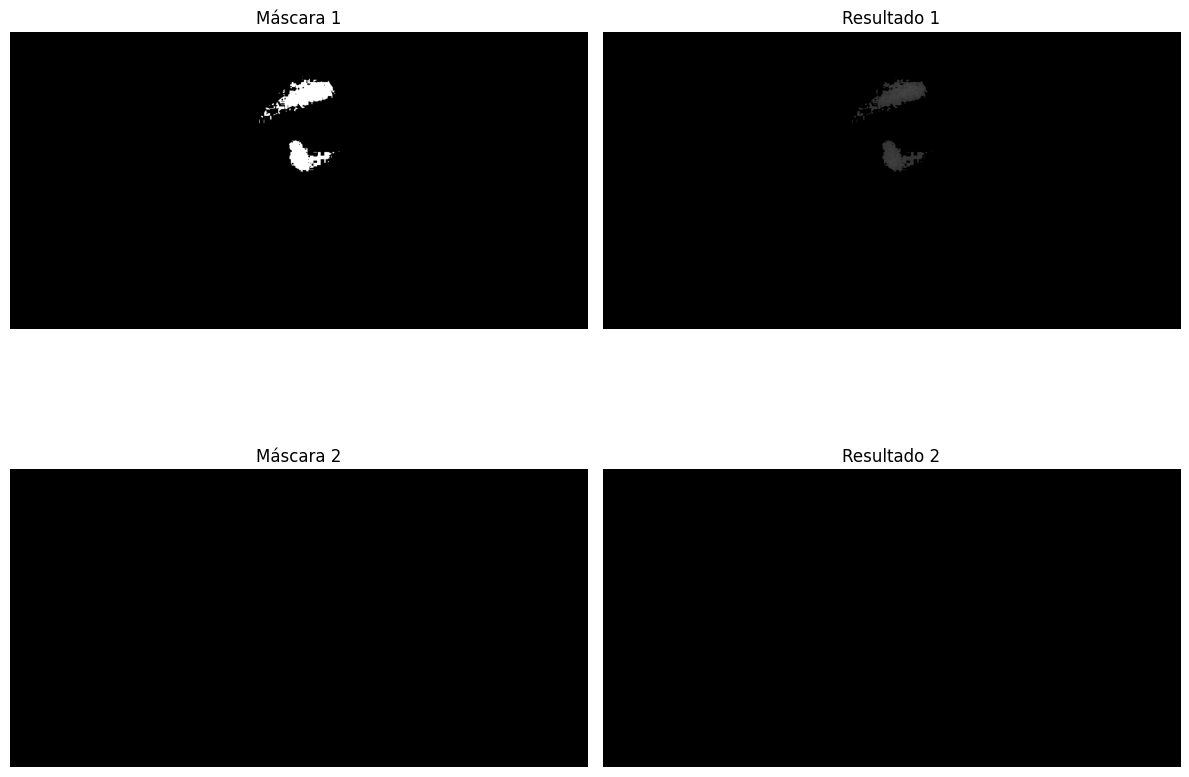

Se probaron dos estrategias de segmentación ajustando los rangos en los canales RGB. En la primera estrategia, con un rango más amplio (50–255), la máscara logra detectar correctamente la zona verde del cuerpo del loro, aunque incluye algo de ruido en regiones con colores similares. En la segunda estrategia, con un rango más restrictivo (90–255), la máscara pierde la mayor parte de la información y no logra detectar correctamente el objeto, ya que muchos píxeles del loro no alcanzan ese nivel en los tres canales simultáneamente. Esto muestra que los valores de color del loro no son tan altos como parecen visualmente y que un rango demasiado estricto elimina información relevante. Por lo tanto, la primera estrategia resulta más adecuada, ya que permite capturar el objeto de interés.


In [16]:
r_min_2, r_max_2 = 90, 255
g_min_2, g_max_2 = 90, 255
b_min_2, b_max_2 = 90, 255

mascara_2 = segmentar_color(imagen_rgb, r_min_2, r_max_2, g_min_2, g_max_2, b_min_2, b_max_2)
resultado_2 = imagen_rgb.copy()
resultado_2[~mascara_2] = 0

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(mascara_1, cmap="gray")
axes[0, 0].set_title("Máscara 1")
axes[0, 0].axis("off")

axes[0, 1].imshow(resultado_1)
axes[0, 1].set_title("Resultado 1")
axes[0, 1].axis("off")

axes[1, 0].imshow(mascara_2, cmap="gray")
axes[1, 0].set_title("Máscara 2")
axes[1, 0].axis("off")

axes[1, 1].imshow(resultado_2)
axes[1, 1].set_title("Resultado 2")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


comparacion = (
    "Se probaron dos estrategias de segmentación ajustando los rangos en los canales RGB. "
    "En la primera estrategia, con un rango más amplio (50–255), la máscara logra detectar correctamente "
    "la zona verde del cuerpo del loro, aunque incluye algo de ruido en regiones con colores similares. "
    "En la segunda estrategia, con un rango más restrictivo (90–255), la máscara pierde la mayor parte "
    "de la información y no logra detectar correctamente el objeto, ya que muchos píxeles del loro no alcanzan "
    "ese nivel en los tres canales simultáneamente. "
    "Esto muestra que los valores de color del loro no son tan altos como parecen visualmente y que un rango "
    "demasiado estricto elimina información relevante. "
    "Por lo tanto, la primera estrategia resulta más adecuada, ya que permite capturar el objeto de interés."
)

print(comparacion)

## Parte 5. Cierre escrito

Respondé con tus palabras:

1. ¿Qué color intentaste segmentar?
2. ¿Qué canales te dieron la pista más útil?
3. ¿Qué ajustes hiciste entre la primera y la segunda estrategia?
4. ¿Qué limitaciones encontraste en este método?
5. Si tuvieras más tiempo, ¿qué mejorarías?

Respuestas:

1. Intenté segmentar el color verde del cuerpo del loro.

2. El canal que dio la pista más útil fue el canal verde (G), ya que esa zona del loro presenta valores más altos en ese canal en comparación con los otros. Esto permitió identificar una diferencia clara respecto al fondo oscuro.

3. En la primera estrategia utilicé un rango más amplio (50–255) en los tres canales, lo que permitió detectar correctamente el loro pero incluyendo algo de ruido. En la segunda estrategia probé un rango más restrictivo (90–255), pero este resultó demasiado estricto y no logró detectar el objeto. Por eso decidí conservar la primera estrategia como la más adecuada.

4. El método RGB tiene limitaciones porque los colores pueden superponerse en los canales. Por ejemplo, otros colores como el amarillo o zonas iluminadas también pueden tener valores altos en el canal verde, generando falsas detecciones. Además, la iluminación influye en los valores de los píxeles y puede afectar la segmentación.

5. Si tuviera más tiempo, probaría segmentar en el espacio de color HSV, ya que permite separar mejor el tono del brillo y sería más robusto para detectar el color verde. También aplicaría operaciones morfológicas para limpiar la máscara y mejorar la continuidad de la región segmentada.


### Lista de control antes de entregar

- Mostré la imagen original.
- Analicé canales e histogramas.
- Probé al menos dos estrategias.
- Elegí una y la justifiqué.
- Escribí una reflexión final clara.
